In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import fsolve
from functools import partial
from matplotlib.lines import Line2D

# used to import local files
import sys  
sys.path.insert(1, '/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv')

from BT_coh_to_fpv import *

def upper_cone_optimize(data, upper = 1000.0, lower = 0.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies below
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie below the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y<= proposed_slope*x+b and x >= xlim])

        # if too few points, we have a new lower bound
        if num_contained_points <= target_point_count:
            lower = proposed_slope
        # if too many points we have a new upper bound
        else:
            upper = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


def lower_cone_optimize(data, upper = 1000.0, lower = -1000.0, precision = 1, data_total = .95, point_on_line = (.5,.5), xlim = .53):
    """
    Find the minimal slope line going through .5,.5 such that data_total percent of data lies above
    the line.

    Upper: the initial slope of the upper bound line
    Lower: the initial slope of the lower bound line.
    Precision: to what distance do we want the upper and lower bound to match.
    data_total: what percent of data should lie above the line.
    point_on_line: a point that must be on the line.

    return m,b where m is the slope and b is the y-intercept
    """
    target_point_count = int(data_total * len([(x,y) for x,y in data if x >= xlim]))
    # print("target", target_point_count)

    proposed_slope = (upper+lower)/2
    b = point_on_line[1]-proposed_slope*point_on_line[0]

    # until we reach desired precision
    while abs(upper-lower) > precision:
        num_contained_points = len([(x,y) for x,y in data if y>= proposed_slope*x+b and x >= xlim])
        # print("num_contained", num_contained_points)

        # if too few points, we have a new upper bound
        if num_contained_points <= target_point_count:
            upper = proposed_slope
        # if too many points we have a new lower bound
        else:
            lower = proposed_slope
        
        # average the old bounds, compute y intercept
        proposed_slope = (upper+lower)/2
        b = point_on_line[1]-proposed_slope*point_on_line[0]
    
    
    return proposed_slope, b


In [2]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]

generators=["slate-CS-C", "slate-CS-W", "slate-BT", "slate-PL"]
colors= {"slate-CS-C":'#1560BD',
        "slate-CS-W":'#FB607F',
         "slate-BT":'#8DB600',
         "slate-PL":'#FFBF00'}

pi_types_dirichlet=["U", "XA", "XB", "BX", "AX", "X"]


dirichlet_markers = {"U":"o", 
"XA":"v", 
"XB":"^",
"BX":"s",
"AX": "d",
"X": "P"}

# Dirichlet


In [3]:
N_TRIALS = 100
N_BALLOTS = 1000
N_SEATS = 6
N_CANDS_PER_BLOC = 6

uniform_dirichlet = 2.0
strong_dirichlet = .5

election_path_name = f'/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/election_results/2_bloc/dirichlet/trials_{N_TRIALS}_ballots_{N_BALLOTS}_seats_{N_SEATS}_cperbloc_{N_CANDS_PER_BLOC}'


In [4]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]

dirichlet_dfs = {}
failed = []
i=0
for b_coh in b_coh_list:
    for g in generators:
        for pi_type in pi_types_dirichlet:
            for b_prop in b_prop_list:
                for a_coh in a_coh_list:
                    if i == 0:
                        print(f"{election_path_name}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}.csv")
                    try:
                        i+=1
                        df = pd.read_csv(f"{election_path_name}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}/b_coh_{b_coh}_a_coh_{a_coh}_b_prop_{b_prop}_{g}_pi_type_{pi_type}_dunif_{uniform_dirichlet}_dstrong_{strong_dirichlet}.csv", index_col=0)
                        dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)] = df
                    except Exception as e:
                        print(e)
                        failed.append((b_coh, a_coh, b_prop, g, pi_type))
                        print(b_coh, a_coh, b_prop, g, pi_type)
                        raise(e)
                   
                    




/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/election_results/2_bloc/dirichlet/trials_100_ballots_1000_seats_6_cperbloc_6/b_coh_0.5_a_coh_0.5_b_prop_0.05_slate-CS-C_pi_type_U_dunif_2.0_dstrong_0.5/b_coh_0.5_a_coh_0.5_b_prop_0.05_slate-CS-C_pi_type_U_dunif_2.0_dstrong_0.5.csv


/tmp/ipykernel_56199/1603740812.py:123: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_56199/1603740812.py:126: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/FULL_{N_SEATS}_seats_combined_support_STV.png", dpi=300)
/cluster/tufts/mggg/cdonna01/.venv_stv_prop/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


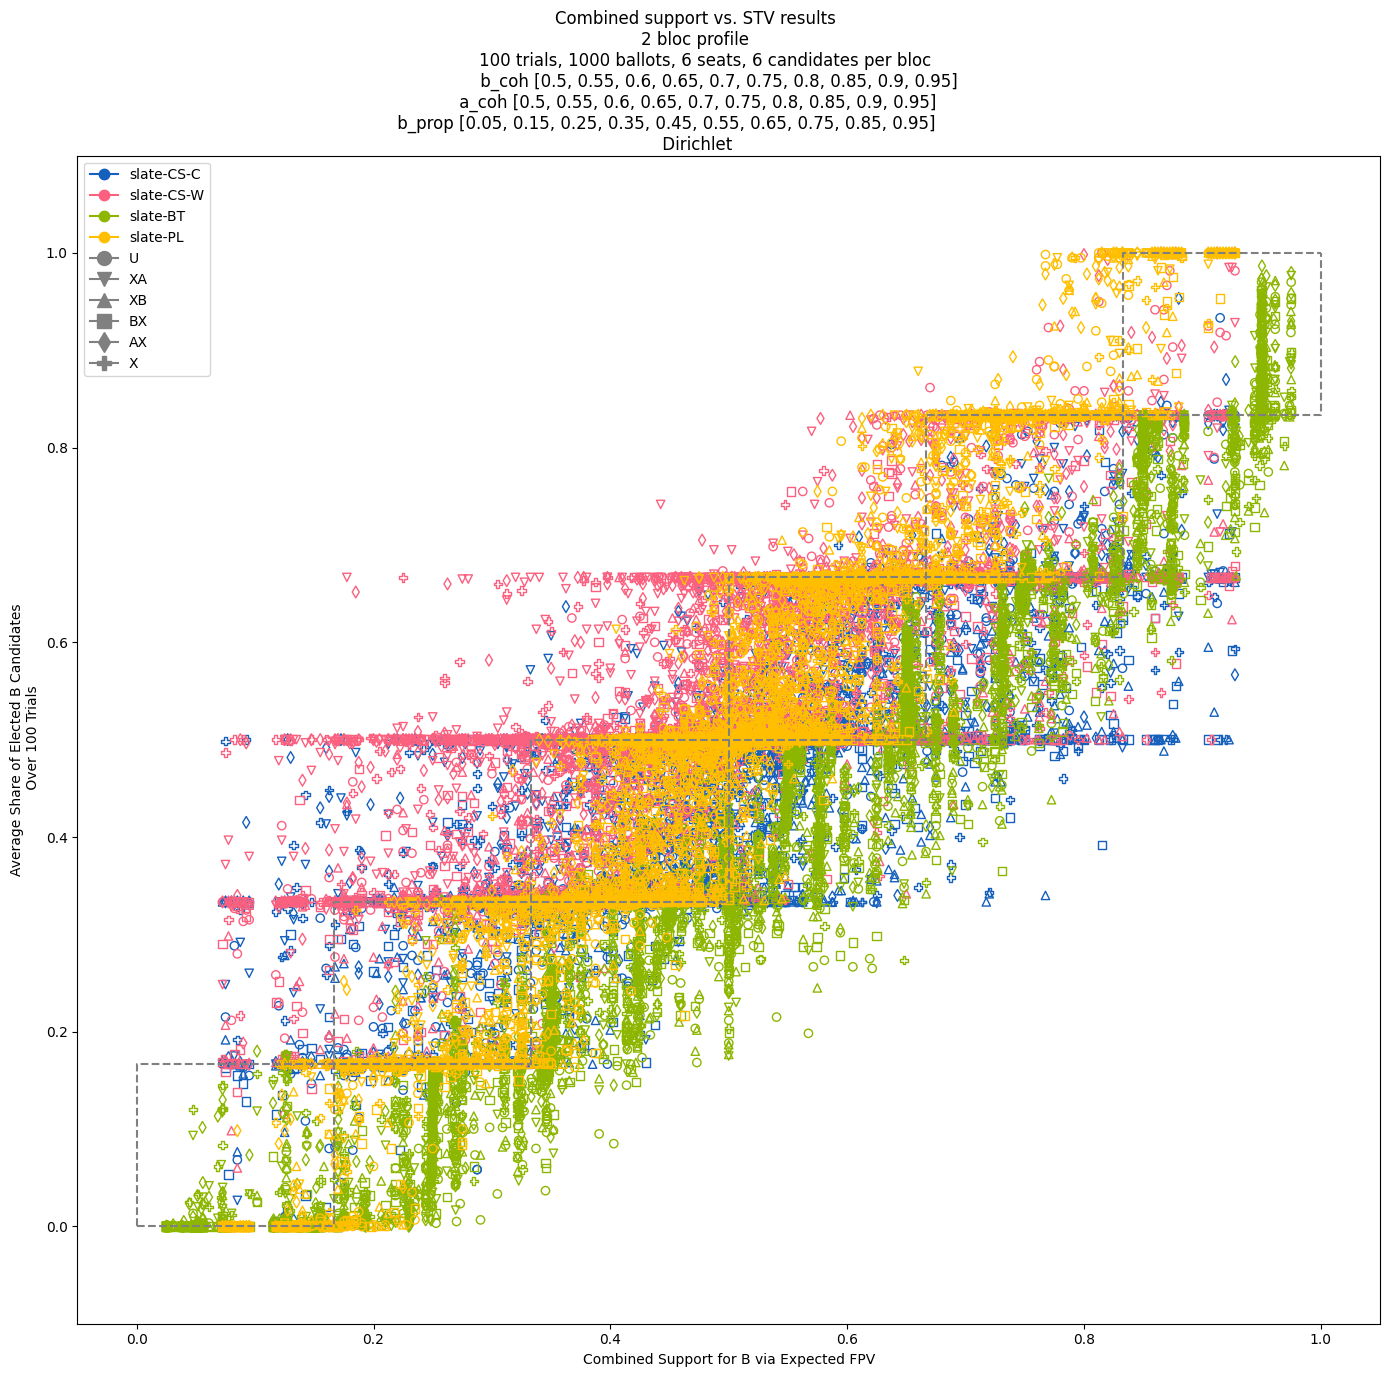

In [5]:
b_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
a_coh_list = [round(x, 2) for x in np.arange(0.5, .99, 0.05)]
b_prop_list = [x/100 for x in range(5, 100, 10)]


LINES = False

# STAT = f"avg borda share for B cands Over {N_TRIALS} Trials"
# STAT = f"avg fpv for B cands Over {N_TRIALS} Trials"
STAT = "Expected FPV"

fig, ax = plt.subplots(figsize=(14,14))
ax.step(
    np.linspace(0,1,N_SEATS+1),
    np.arange(0,1.1, 1/N_SEATS),
    linestyle = 'dashed',
    c='gray',
    where='pre'
)
ax.step(
    np.linspace(0,1,N_SEATS+1),
    np.arange(0,1.1, 1/N_SEATS),
    linestyle = 'dashed',
    c='gray',
    where='post'
)
ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
ax.set_xlabel(f'Combined Support for B via {STAT}')

data  = [-1]* len(generators)*len(b_prop_list)*len(pi_types_dirichlet)*len(b_coh_list)*len(a_coh_list)
i=0
# for g in generators:
for g in ["slate-PL"]:
    for b_prop in b_prop_list:
        # for pi_type in ["U"]:
        for pi_type in pi_types_dirichlet:
            for b_coh in b_coh_list:
                if "BT" in g:
                    fpv_b = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, b_coh)
                else:
                    fpv_b=b_coh
                for a_coh in a_coh_list:
                    if "BT" in g:
                        fpv_a = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, a_coh)
                    else:
                        fpv_a=a_coh
                    df = dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)]
                    
                    # combined support
                    if "borda" in STAT:
                        x=np.average(df["B Borda shares"])

                    elif "observed avg fpv" in STAT:
                        x=np.average(df["B fpv"])
                    
                    else:
                        x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                    
                    # average seats over trials
                    y = np.average(df["B cands elected"])/N_SEATS 

                    if LINES:
                        data[i]=(x,y)
                        i+=1               
                    ax.scatter(x, y,
                            label=g,
                            marker = dirichlet_markers[pi_type],
                            edgecolor=colors[g], 
                            facecolor='none'
                        )
                        # ax.text(x,y, s=str((p, b_prop, a_coh)))
            


if LINES:
    x = np.linspace(0, 1, 100)  
    m_1,b_1 = upper_cone_optimize(data, 
                upper = 1000.0, 
                lower = -1000.0, 
                precision = .01, 
                data_total = .95, 
                point_on_line = (.5, .5), 
                xlim = .53)
    y = m_1*x+b_1
    plt.plot(x,y, label = f"upper cone {m_1:.2f}x+{b_1:.2f}", color="red")

    m_2,b_2 = lower_cone_optimize(data, 
                upper = 1000.0, 
                lower = -1000.0, 
                precision = .01, 
                data_total = .95, 
                point_on_line = (.5, .5), 
                xlim = .53)
    y = m_2*x+b_2
    plt.plot(x,y, label = f"lower cone {m_2:.2f}x+{b_2:.2f}", color="blue")

    # line of best fit
    x,y = zip(*data)
    m_3=np.polyfit(x, y, 1)[0]
    b_3=np.polyfit(x, y, 1)[1]
    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")


legend_elements = [
    Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
    for g in generators
] + [Line2D([0], [0], marker=dirichlet_markers[pi_type], color="grey", label=pi_type, markersize=10)
    for pi_type in pi_types_dirichlet] 

if LINES:
    legend_elements += [Line2D([0], [0], color="red", label = f"upper cone {m_1:.2f}x+{b_1:.2f}")
    ] + \
    [Line2D([0], [0], color="blue", label = f"lower cone {m_2:.2f}x+{b_2:.2f}")]+ \
    [Line2D([0], [0], color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]


plt.ylim(-.1, 1.1)
plt.legend(handles=legend_elements)
plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n\
    {N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n\
         b_coh {b_coh_list}\n a_coh {a_coh_list}\n b_prop {b_prop_list}\
            \n Dirichlet")
plt.tight_layout()
# plt.show()
try:
    plt.savefig(f"/cluster/tufts/mggg/cdonna01/EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/sPL_{N_SEATS}_seats_combined_support_STV.png", dpi=300)
except:
    try:
        plt.savefig(f"figures/2_bloc/dirichlet/sPL_{N_SEATS}_seats_combined_support_STV.png", dpi=300)
        
    except:
        plt.savefig(f"sPL_{N_SEATS}_seats_combined_support_STV.png", dpi=300)


# Checking slopes

In [8]:
slopes = {"generator":[],
            "pi_type":[],
            "cohesion":[],
            "UC m":[],
            "UC b": [],
            "LC m":[],
            "LC b": [],
            "LOBF m":[],
            "LOBF b": [],}

STAT = f"avg borda share for B cands Over {N_TRIALS} Trials"
# STAT = f"avg fpv for B cands Over {N_TRIALS} Trials"
# STAT = "Expected FPV"

for g in generators:
    for pi_type in pi_types_dirichlet:
        for cohesion in ["full", "polarized"]:
            print(g, pi_type, f"cohesion {cohesion}")
            slopes["generator"].append(g)
            slopes["pi_type"].append(pi_type)
            slopes["cohesion"].append(cohesion)

            if cohesion == "full":
                b_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
                a_coh_list = [round(x, 2) for x in np.arange(0.55, .99, 0.05)]
            else:
                b_coh_list = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]
                a_coh_list = [round(x, 2) for x in np.arange(0.7, .99, 0.05)]


            b_prop_list = [x/100 for x in range(5, 100, 10)]

            for lines in [True, False]:
                fig, ax = plt.subplots(figsize=(14,14))
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='pre'
                )
                ax.step(
                    np.linspace(0,1,N_SEATS+1),
                    np.arange(0,1.1, 1/N_SEATS),
                    linestyle = 'dashed',
                    c='gray',
                    where='post'
                )
                ax.set_ylabel(f'Average Share of Elected B Candidates\n Over {N_TRIALS} Trials')
                ax.set_xlabel(f'Combined Support for B via {STAT}')
            
                data  = []
                for b_prop in b_prop_list:
                    for b_coh in b_coh_list:
                        if "BT" in g:
                            fpv_b = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, b_coh)
                        else:
                            fpv_b=b_coh
                        for a_coh in a_coh_list:
                            if "BT" in g:
                                fpv_a = slate_BT_coh_to_fpv(N_CANDS_PER_BLOC, N_CANDS_PER_BLOC, a_coh)
                            else:
                                fpv_a=a_coh
                            df = dirichlet_dfs[(b_coh, g, pi_type, b_prop, a_coh)]
                            # combined support
                            if "borda" in STAT:
                                x=np.average(df["B Borda shares"])
                            elif "observed avg fpv" in STAT:
                                x=np.average(df["B fpv"])
                            else:
                                x = fpv_b*b_prop  + (1-fpv_a)*(1-b_prop)
                            
                            # average seats over trials
                            y = np.average(df["B cands elected"])/N_SEATS 

                            data.append((x,y))
                            ax.scatter(x, y,
                            label=g,
                            marker = dirichlet_markers[pi_type],
                            edgecolor=colors[g], 
                            facecolor=colors[g]
                        )
                        
                        

            
                if lines:                
                    x = np.linspace(0, 1, 100)  
                    m_1,b_1 = upper_cone_optimize(data, 
                                upper = 1000.0, 
                                lower = -1000.0, 
                                precision = .01, 
                                data_total = .95, 
                                point_on_line = (.5, .5), 
                                xlim = .53)
                    y = m_1*x+b_1
                    plt.plot(x,y, label = f"upper cone {m_1:.2f}x+{b_1:.2f}", color="red")
                    print(f"upper cone {m_1:.2f}x+{b_1:.2f}")
                    slopes["UC m"].append(m_1)
                    slopes["UC b"].append(b_1)

                    # print("lower cone")
                    m_2,b_2 = lower_cone_optimize(data, 
                                upper = 1000.0, 
                                lower = -1000.0, 
                                precision = .01, 
                                data_total = .95, 
                                point_on_line = (.5, .5), 
                                xlim = .53)
                    y = m_2*x+b_2
                    plt.plot(x,y, label = f"lower cone {m_2:.2f}x+{b_2:.2f}", color="blue")

                    print(f"lower cone {m_2:.2f}x+{b_2:.2f}")
                    slopes["LC m"].append(m_2)
                    slopes["LC b"].append(b_2)

                    # line of best fit
                    x,y = zip(*data)
                    m_3=np.polyfit(x, y, 1)[0]
                    b_3=np.polyfit(x, y, 1)[1]
                    plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)), color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")

                    print(f"LOBF {m_3:.2f}x+{b_3:.2f}\n")
                    slopes["LOBF m"].append(m_3)
                    slopes["LOBF b"].append(b_3)

                    legend_elements = [
                        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                        for g in [g]
                    ] + [Line2D([0], [0], marker=dirichlet_markers[pi_type], color="grey", label=pi_type, markersize=10)
                        for pi_type in [pi_type]] +\
                        [Line2D([0], [0], color="red", label = f"upper cone {m_1:.2f}x+{b_1:.2f}")
                        ] + \
                        [Line2D([0], [0], color="blue", label = f"lower cone {m_2:.2f}x+{b_2:.2f}")]+ \
                        [Line2D([0], [0], color="green", ls="dashed", label=f"LOBF {m_3:.2f}x+{b_3:.2f}")]
                else:
                    legend_elements = [
                        Line2D([0], [0], marker='.', color=colors[g], label=g, markersize=15)
                        for g in [g]
                    ] + [Line2D([0], [0], marker=dirichlet_markers[pi_type], color="grey", label=pi_type, markersize=10)
                        for pi_type in [pi_type]]

                plt.ylim(-.1, 1.1)
                plt.legend(handles=legend_elements)
                plt.suptitle(f"Combined support vs. STV results\n2 bloc profile\n{N_TRIALS} trials, {N_BALLOTS} ballots, {N_SEATS} seats, {N_CANDS_PER_BLOC} candidates per bloc\n pi_B {b_coh_list}\n pi_A {a_coh_list}\n b_prop {b_prop_list}\n Dirichlet")
                plt.tight_layout()
                # plt.show()

                if lines:
                    plt.savefig(f"EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/line_fit/{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.pdf")
                else:
                    plt.savefig(f"EC_paper/refactored_2_bloc_stv/figures/2_bloc/dirichlet/{N_SEATS}_seats_{STAT}_combined_support_STV_{g}_{pi_type}_{cohesion}.pdf")
                
                plt.close()
        
    
    

data_frame = pd.DataFrame.from_dict(slopes)
data_frame.to_csv(f"EC_paper/refactored_2_bloc_stv/slope_data/dirichlet/{N_SEATS}_seats_slopes_2_bloc_stv_{STAT}.csv")

slate-CS-C U cohesion full
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 4.67x+-1.46

slate-CS-C U cohesion polarized
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 4.69x+-1.46

slate-CS-C XA cohesion full
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 3.32x+-0.84

slate-CS-C XA cohesion polarized
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 3.22x+-0.79

slate-CS-C XB cohesion full
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 3.64x+-1.04

slate-CS-C XB cohesion polarized
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 3.66x+-1.04

slate-CS-C BX cohesion full
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 4.15x+-1.23

slate-CS-C BX cohesion polarized
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 4.18x+-1.24

slate-CS-C AX cohesion full
upper cone 1000.00x+-499.50
lower cone -1000.00x+500.50
LOBF 3.03x+-0.74

slate-CS-C AX cohesion polarized
upper cone 1000.00x+-499.50
low